**KHAI BÁO THƯ VIỆN**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import keras
from keras import layers, models
from keras.applications import DenseNet201
import gradio as gr
import kagglehub
import warnings

warnings.filterwarnings('ignore')

**LOAD DATESETS TỪ KAGGLE**

In [ ]:
print("Đang tải dữ liệu...")
try:
    path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")
    print(f"Tải thành công tại: {path}")
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")
    path = ""

Đang tải dữ liệu...
Using Colab cache for faster access to the 'rice-leaf-diseases' dataset.
Tải thành công tại: /kaggle/input/rice-leaf-diseases


In [ ]:
if path:
    target_dir = os.path.join(path, "rice_leaf_diseases")

    if os.path.exists(target_dir):
        data_dir = target_dir
    else:
        data_dir = path

    print(f"Đường dẫn chốt để xử lý: {data_dir}")
    print(f"   Các lớp tìm thấy: {os.listdir(data_dir)}")
else:
    print("Không có đường dẫn dữ liệu. Vui lòng kiểm tra lại mạng.")

Đường dẫn chốt để xử lý: /kaggle/input/rice-leaf-diseases/rice_leaf_diseases
   Các lớp tìm thấy: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


Đã tìm thấy 3 lớp bệnh: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


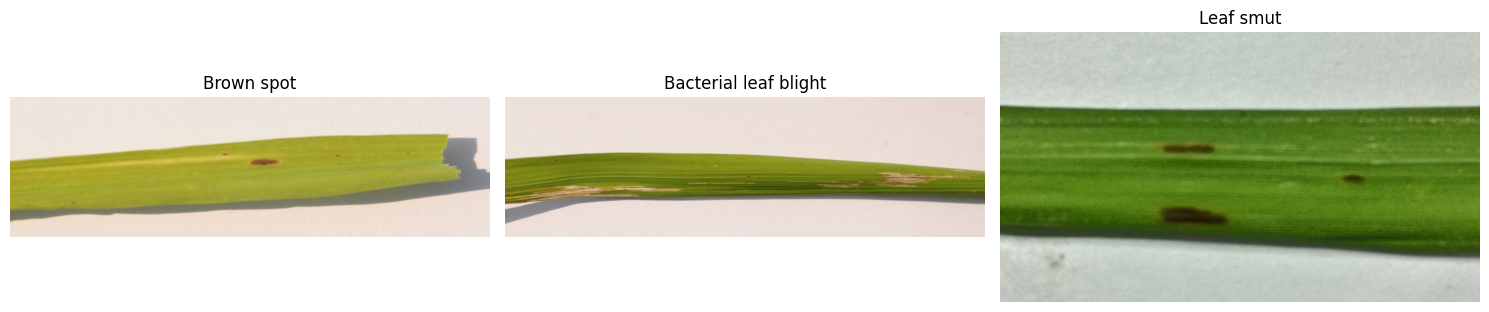

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print(f"Đã tìm thấy {len(classes)} lớp bệnh: {classes}")

plt.figure(figsize=(15, 5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    file_list = os.listdir(class_path)

    if len(file_list) > 0:
        # Chọn ngẫu nhiên 1 file ảnh trong thư mục đó
        rand_img = random.choice(file_list)
        img_path = os.path.join(class_path, rand_img)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(classes), i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
        except Exception as e:
            print(f"Lỗi đọc ảnh {rand_img}: {e}")

plt.tight_layout()
plt.show()

Đang phân tích chi tiết dữ liệu...


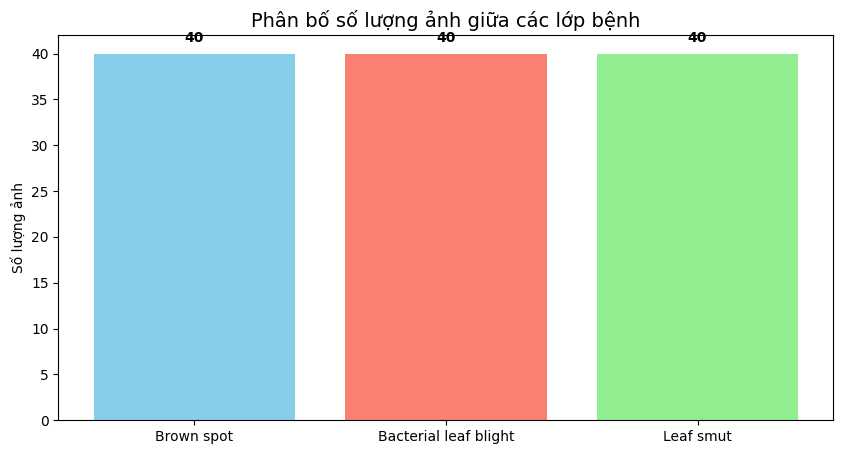


--- KẾT QUẢ PHÂN TÍCH ---
1. Tổng số ảnh toàn bộ: 120
Đánh giá: Dữ liệu tương đối cân bằng. Tốt cho việc huấn luyện.

2. Kích thước ảnh gốc (Width, Height): {(4160, 2340), (1480, 279), (741, 291), (766, 250), (3081, 897), (1530, 371), (562, 217), (296, 88), (250, 200)}


In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Biến lưu trữ thông tin
class_counts = {} # Đếm số lượng
shapes = []       # Lưu kích thước

print("Đang phân tích chi tiết dữ liệu...")

# Duyệt qua từng lớp để thu thập thông tin
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        # 1. Lưu số lượng ảnh
        class_counts[class_name] = len(files)

        # 2. Kiểm tra kích thước (lấy mẫu 10 ảnh mỗi lớp để kiểm tra nhanh)
        for f in files[:10]:
            try:
                with Image.open(os.path.join(class_path, f)) as img:
                    shapes.append(img.size) # Lưu (Width, Height)
            except:
                pass

# 1. Vẽ biểu đồ cột so sánh số lượng
names = list(class_counts.keys())
values = list(class_counts.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(names, values, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Phân bố số lượng ảnh giữa các lớp bệnh', fontsize=14)
plt.ylabel('Số lượng ảnh')

# Hiển thị số cụ thể trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')
plt.show()

# 2. Đánh giá tự động
print(f"\n--- KẾT QUẢ PHÂN TÍCH ---")
print(f"1. Tổng số ảnh toàn bộ: {sum(values)}")

# Kiểm tra cân bằng
max_val = max(values)
min_val = min(values)
if (max_val - min_val) / max_val > 0.5:
    print("CẢNH BÁO: Dữ liệu mất cân bằng (Imbalanced). Lớp nhiều ảnh gấp đôi lớp ít ảnh.")
    print("   -> Giải pháp: Có thể cần Data Augmentation (tăng cường dữ liệu) cho lớp ít ảnh.")
else:
    print("Đánh giá: Dữ liệu tương đối cân bằng. Tốt cho việc huấn luyện.")

# Kiểm tra kích thước
unique_shapes = set(shapes)
print(f"\n2. Kích thước ảnh gốc (Width, Height): {unique_shapes}")

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Dữ liệu ít nên giảm batch size xuống

# 1. Tạo lớp Tăng cường dữ liệu (Data Augmentation)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), # Lật ảnh ngẫu nhiên
    layers.RandomRotation(0.2), # Xoay ảnh 20%
    layers.RandomZoom(0.2),     # Zoom ảnh
])

# 2. Load dữ liệu và chia tập Train (80%) / Validation (20%)
# Lưu ý: Chúng ta load ảnh gốc, việc resize sẽ thực hiện ngay khi load
train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

# 3. Áp dụng Augmentation cho tập Train
# (Chỉ augmentation tập train, tập validation giữ nguyên để kiểm tra trung thực)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 4. Chuẩn hóa pixel (0-255 -> 0-1) cho cả 2 tập
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Tối ưu hiệu năng
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Đã xử lý xong: Resize, Augmentation và Chuẩn hóa.")

Found 120 files belonging to 3 classes.
Using 96 files for training.
Found 120 files belonging to 3 classes.
Using 24 files for validation.
Đã xử lý xong: Resize, Augmentation và Chuẩn hóa.


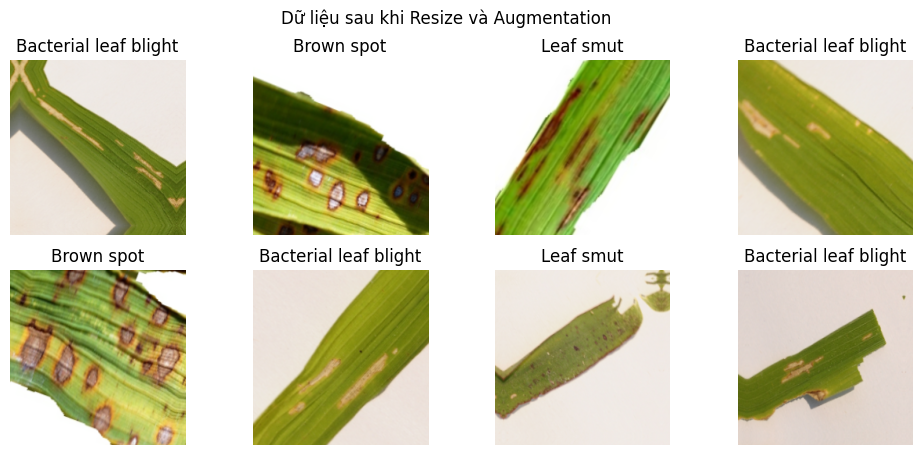

In [ ]:
plt.figure(figsize=(12, 5))
# Lấy 1 batch từ tập train đã augment
for images, labels in train_ds.take(1):
    for i in range(8): # Xem 8 ảnh
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Dữ liệu sau khi Resize và Augmentation")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

# Định nghĩa các đuôi file ảnh chấp nhận
valid_exts = ['jpeg', 'jpg', 'bmp', 'png', 'gif']

def check_data_validity(directory):
    print(f" Đang kiểm tra dữ liệu tại: {directory} ...\n")

    files_checked = 0
    files_error = 0
    files_removed = 0

    # Duyệt qua từng thư mục con (lớp bệnh)
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        # Bỏ qua nếu không phải thư mục
        if not os.path.isdir(folder_path):
            continue

        print(f"    Đang quét lớp: {folder_name}")

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            files_checked += 1

            try:
                # 1. Kiểm tra đuôi file (Extension check)
                ext = filename.split('.')[-1].lower()
                if ext not in valid_exts:
                    print(f"       Sai định dạng (không phải ảnh): {filename}")
                    files_error += 1
                    # os.remove(file_path) # Bỏ comment nếu muốn xóa
                    continue

                # 2. Kiểm tra bằng PIL (Header check)
                # PIL giúp phát hiện ảnh bị lỗi header hoặc file rỗng
                with Image.open(file_path) as img:
                    img.verify() # Chỉ check cấu trúc, không load ảnh vào RAM -> Nhanh

                # 3. Kiểm tra bằng OpenCV (Pixel check)
                # Đôi khi PIL mở được nhưng OpenCV thì không (do lỗi pixel data)
                # Vì lúc train ta dùng Keras/OpenCV nên bước này rất quan trọng
                img_cv = cv2.imread(file_path)
                if img_cv is None:
                    print(f"       Ảnh hỏng (OpenCV không đọc được): {filename}")
                    files_error += 1
                    # os.remove(file_path) # Bỏ comment nếu muốn xóa
                    # files_removed += 1

            except (IOError, SyntaxError) as e:
                print(f"       File lỗi (Corrupt): {filename} - {e}")
                files_error += 1
                # os.remove(file_path) # Bỏ comment nếu muốn xóa
                # files_removed += 1

    print("\n" + "="*40)
    print(f"HOÀN TẤT KIỂM TRA!")
    print(f"Tổng số file đã quét: {files_checked}")
    print(f"Tổng số file lỗi: {files_error}")
    # print(f"Tổng số file đã xóa: {files_removed}")
    print("="*40)

# Chạy hàm kiểm tra với đường dẫn data_dir bạn đã có
# Lưu ý: Biến data_dir lấy từ các bước trước
if 'data_dir' in globals():
    check_data_validity(data_dir)
else:
    print("Chưa tìm thấy biến data_dir. Hãy chạy bước tải dữ liệu trước!")

 Đang kiểm tra dữ liệu tại: /kaggle/input/rice-leaf-diseases/rice_leaf_diseases ...

    Đang quét lớp: Brown spot
    Đang quét lớp: Bacterial leaf blight
    Đang quét lớp: Leaf smut

HOÀN TẤT KIỂM TRA!
Tổng số file đã quét: 120
Tổng số file lỗi: 0


In [ ]:
import tensorflow as tf
import keras # Import trực tiếp Keras
from keras import layers # Lấy layers từ Keras gốc

# Cấu hình
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

print("Đang thiết lập pipeline xử lý dữ liệu...")

# 1. Định nghĩa lớp Tăng cường dữ liệu (Data Augmentation)
# Dùng keras.Sequential thay vì tf.keras.Sequential
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

# 2. Load dữ liệu gốc
# Dùng keras.utils.image_dataset_from_directory
train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Các nhãn bệnh: {class_names}")

# 3. Áp dụng giải pháp vào dữ liệu
def preprocess_train(image, label):
    # Augmentation
    image = data_augmentation(image)
    # Chuẩn hóa 0-1
    image = layers.Rescaling(1./255)(image)
    return image, label

def preprocess_val(image, label):
    # Validation chỉ cần chuẩn hóa
    image = layers.Rescaling(1./255)(image)
    return image, label

# Map hàm xử lý vào dataset
train_ds = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)

# Cache dữ liệu
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Đã xử lý xong! Dữ liệu train đã được nhân bản ngẫu nhiên.")

Đang thiết lập pipeline xử lý dữ liệu...
Found 120 files belonging to 3 classes.
Using 96 files for training.
Found 120 files belonging to 3 classes.
Using 24 files for validation.
Các nhãn bệnh: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Đã xử lý xong! Dữ liệu train đã được nhân bản ngẫu nhiên.


THỐNG KÊ DỮ LIỆU SAU KHI BATCHING:
1. Tập Huấn luyện (Train):
   - Số lượng Batch: 6
   - Ước lượng số ảnh: ~96 ảnh
2. Tập Kiểm thử (Validation):
   - Số lượng Batch: 2
   - Ước lượng số ảnh: ~32 ảnh
----------------------------------------
HIỂN THỊ MẪU DỮ LIỆU ĐÃ QUA AUGMENTATION:


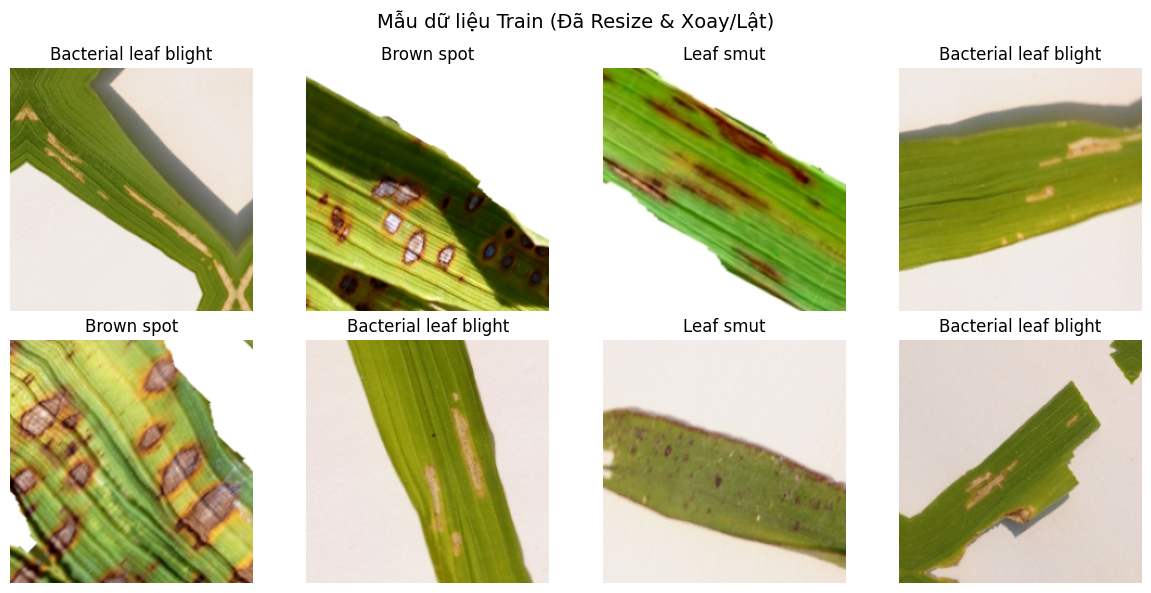

In [ ]:
# --- PHẦN 1: HIỂN THỊ THỐNG KÊ SỐ LƯỢNG ---
print("THỐNG KÊ DỮ LIỆU SAU KHI BATCHING:")

# Tính toán số lượng batch
train_batches = len(train_ds)
val_batches = len(val_ds)

# Ước lượng tổng số ảnh (Lưu ý: batch cuối có thể ít hơn BATCH_SIZE)
print(f"1. Tập Huấn luyện (Train):")
print(f"   - Số lượng Batch: {train_batches}")
print(f"   - Ước lượng số ảnh: ~{train_batches * BATCH_SIZE} ảnh")

print(f"2. Tập Kiểm thử (Validation):")
print(f"   - Số lượng Batch: {val_batches}")
print(f"   - Ước lượng số ảnh: ~{val_batches * BATCH_SIZE} ảnh")
print("-" * 40)

# --- PHẦN 2: TRỰC QUAN HÓA ẢNH ĐÃ XỬ LÝ ---
print("HIỂN THỊ MẪU DỮ LIỆU ĐÃ QUA AUGMENTATION:")

plt.figure(figsize=(12, 6))

# Lấy ra 1 batch (nhóm ảnh) đầu tiên từ tập train để xem
# next(iter(train_ds)) giúp lấy dữ liệu nhanh mà không cần vòng lặp
images, labels = next(iter(train_ds))

# Hiển thị 8 ảnh đầu tiên trong batch
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)

    # Chuyển tensor sang numpy array để vẽ
    img_array = images[i].numpy()

    # Vẽ ảnh
    plt.imshow(img_array)

    # Lấy tên nhãn
    label_index = int(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")

plt.suptitle("Mẫu dữ liệu Train (Đã Resize & Xoay/Lật)", fontsize=14)
plt.tight_layout()
plt.show()

Đang tạo các biểu đồ phân tích...


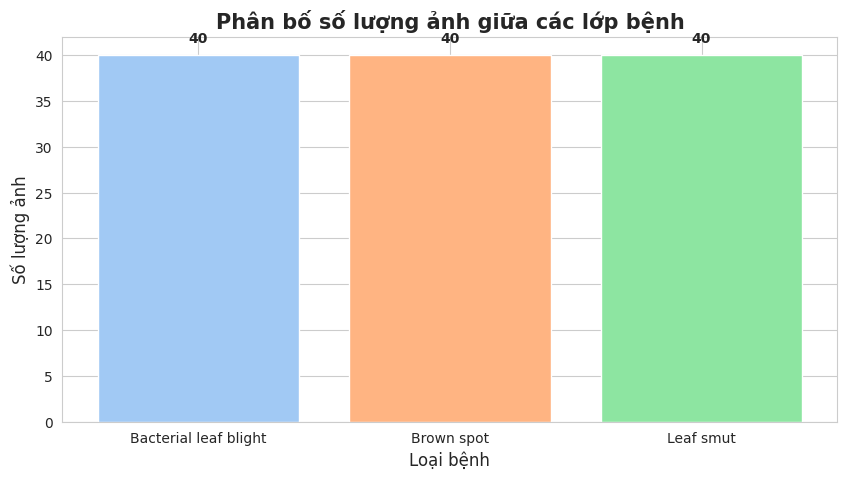

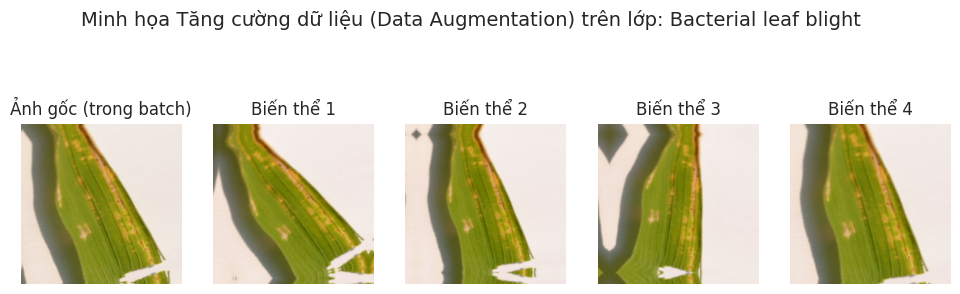

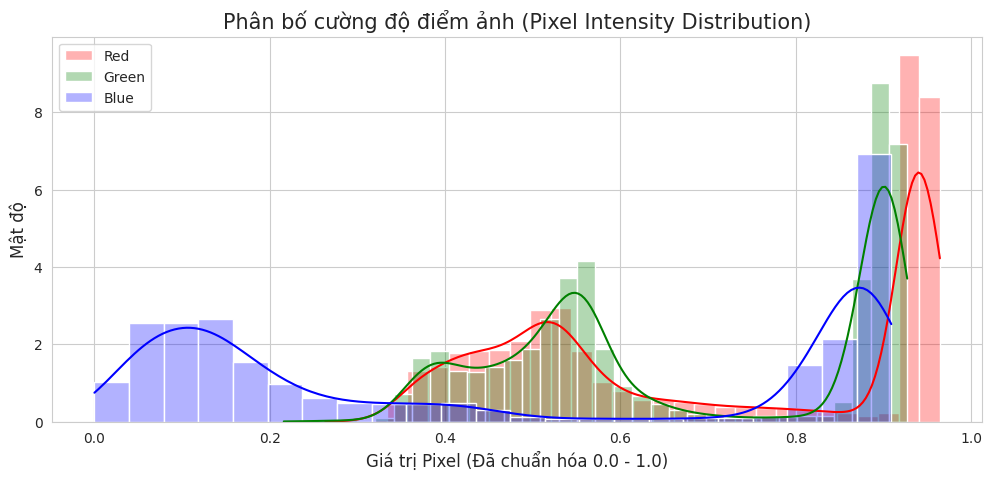

In [ ]:
import seaborn as sns

# Cấu hình giao diện biểu đồ cho đẹp
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Đang tạo các biểu đồ phân tích...")

# --- BIỂU ĐỒ 1: PHÂN BỐ SỐ LƯỢNG ẢNH (BAR CHART) ---
# Đếm số lượng file trong mỗi thư mục
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    if os.path.exists(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
colors = sns.color_palette('pastel')[0:len(class_names)]
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors)

plt.title('Phân bố số lượng ảnh giữa các lớp bệnh', fontsize=15, fontweight='bold')
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xlabel('Loại bệnh', fontsize=12)

# Hiển thị con số trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')
plt.show()


# --- BIỂU ĐỒ 2: HIỆU QUẢ CỦA DATA AUGMENTATION ---
# Lấy 1 ảnh mẫu từ tập train
images, labels = next(iter(train_ds))
sample_img = images[0] # Lấy ảnh đầu tiên trong batch
sample_label = class_names[labels[0]]

plt.figure(figsize=(12, 4))
plt.suptitle(f"Minh họa Tăng cường dữ liệu (Data Augmentation) trên lớp: {sample_label}", fontsize=14)

# Vẽ ảnh gốc (trong batch đã xử lý)
ax = plt.subplot(1, 5, 1)
plt.imshow(sample_img)
plt.title("Ảnh gốc (trong batch)")
plt.axis("off")

# Vẽ 4 biến thể ngẫu nhiên
for i in range(4):
    # Áp dụng lớp augmentation thủ công để demo
    augmented_img = data_augmentation(tf.expand_dims(sample_img, 0))
    ax = plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_img[0])
    plt.title(f"Biến thể {i+1}")
    plt.axis("off")
plt.show()


# --- BIỂU ĐỒ 3: HISTOGRAM PHÂN BỐ MÀU SẮC (RGB) ---
# Kiểm tra xem lá lúa có màu gì chủ đạo và dữ liệu đã chuẩn hóa chưa
plt.figure(figsize=(12, 5))

# Tách các kênh màu R, G, B từ ảnh mẫu
# Vì ảnh đã chuẩn hóa 0-1, ta nhân lại 255 để dễ nhìn hoặc để nguyên 0-1
img_array = sample_img.numpy()

sns.histplot(img_array[:, :, 0].ravel(), color='red', label='Red', kde=True, stat="density", alpha=0.3)
sns.histplot(img_array[:, :, 1].ravel(), color='green', label='Green', kde=True, stat="density", alpha=0.3)
sns.histplot(img_array[:, :, 2].ravel(), color='blue', label='Blue', kde=True, stat="density", alpha=0.3)

plt.title('Phân bố cường độ điểm ảnh (Pixel Intensity Distribution)', fontsize=15)
plt.xlabel('Giá trị Pixel (Đã chuẩn hóa 0.0 - 1.0)', fontsize=12)
plt.ylabel('Mật độ', fontsize=12)
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split


# Hàm hỗ trợ lấy dữ liệu từ TensorFlow Dataset ra dạng Numpy
def get_numpy_data(dataset):
    X_list = []
    y_list = []
    for images, labels in dataset:
        # Chuyển tensor sang numpy
        X_list.append(images.numpy())
        y_list.append(labels.numpy())

    # Gộp các batch lại thành mảng lớn
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y

X_train_dl, y_train = get_numpy_data(train_ds)
X_test_dl, y_test = get_numpy_data(val_ds)

X_train_flat = X_train_dl.reshape(X_train_dl.shape[0], -1)
X_test_flat = X_test_dl.reshape(X_test_dl.shape[0], -1)

print(f"   - Kích thước tập Train: {X_train_flat.shape}")
print(f"   - Kích thước tập Test: {X_test_flat.shape}")

   - Kích thước tập Train: (96, 150528)
   - Kích thước tập Test: (24, 150528)


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- THUẬT TOÁN 1: SUPPORT VECTOR MACHINE (SVM) ---
print("\n 1. Đang huấn luyện SVM (Support Vector Machine)...")
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_flat, y_train)

# Dự đoán
y_pred_svm = svm_model.predict(X_test_flat)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"    Độ chính xác SVM: {acc_svm:.2%}")

# --- THUẬT TOÁN 2: RANDOM FOREST ---
print("\n 2. Đang huấn luyện Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"    Độ chính xác Random Forest: {acc_rf:.2%}")


 1. Đang huấn luyện SVM (Support Vector Machine)...
    Độ chính xác SVM: 58.33%

 2. Đang huấn luyện Random Forest...
    Độ chính xác Random Forest: 62.50%


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.applications import DenseNet201

print("\n🧠 3. Đang huấn luyện Deep Learning (DenseNet201)...")

# Xây dựng lại model (để đảm bảo mới hoàn toàn)
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

dl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='softmax')
])

dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
history = dl_model.fit(train_ds, validation_data=val_ds, epochs=20, verbose=0) # verbose=0 để ẩn log dài dòng

# Dự đoán lấy kết quả
loss, acc_dl = dl_model.evaluate(val_ds, verbose=0)
# Lấy dự đoán dạng class (0, 1, 2) thay vì xác suất
y_prob_dl = dl_model.predict(val_ds)
y_pred_dl = np.argmax(y_prob_dl, axis=1)

print(f"   👉 Độ chính xác DenseNet201: {acc_dl:.2%}")


🧠 3. Đang huấn luyện Deep Learning (DenseNet201)...
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 9s/step
   👉 Độ chính xác DenseNet201: 100.00%


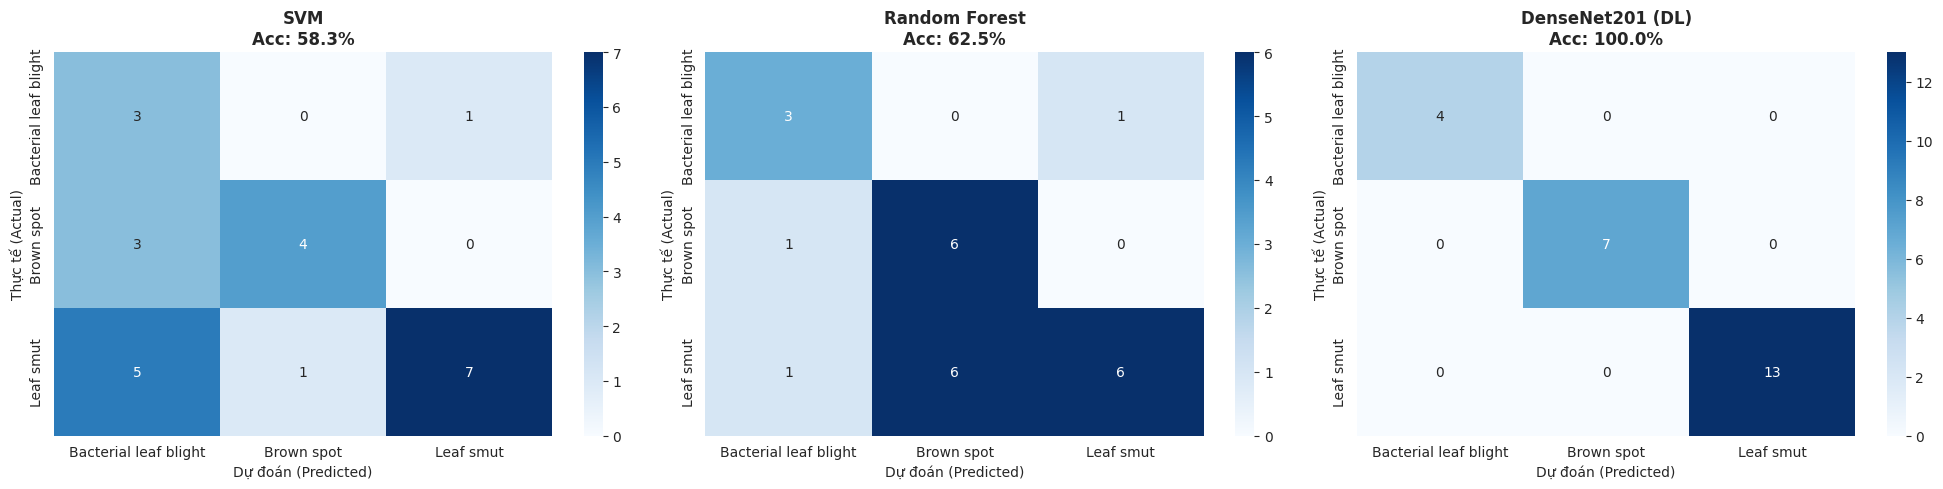

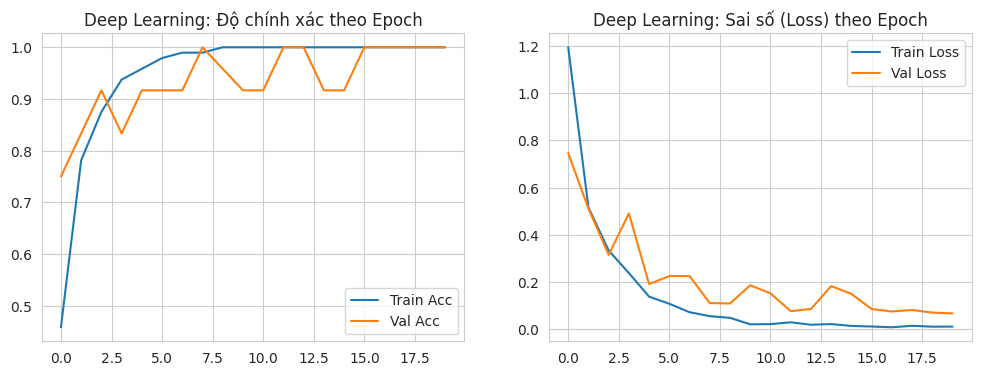

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Hàm vẽ Confusion Matrix chuyên nghiệp
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dự đoán (Predicted)')
    ax.set_ylabel('Thực tế (Actual)')

# Thiết lập khung vẽ 3 biểu đồ ngang nhau
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Vẽ cho SVM
plot_cm(y_test, y_pred_svm, f"SVM\nAcc: {acc_svm:.1%}", axes[0])

# 2. Vẽ cho Random Forest
plot_cm(y_test, y_pred_rf, f"Random Forest\nAcc: {acc_rf:.1%}", axes[1])

# 3. Vẽ cho Deep Learning
# Lưu ý: Với DL, y_test có thể cần lấy lại từ val_ds nếu thứ tự bị xáo trộn (nhưng với cấu hình shuffle=False khi test thì ok)
# Ở đây ta dùng y_test từ bước convert numpy đầu tiên vì nó khớp với val_ds
plot_cm(y_test, y_pred_dl, f"DenseNet201 (DL)\nAcc: {acc_dl:.1%}", axes[2])

plt.tight_layout()
plt.show()

# --- VẼ BIỂU ĐỒ LOSS/ACCURACY CHO DEEP LEARNING ---
# Vì ML truyền thống không có history theo epoch như DL
plt.figure(figsize=(12, 4))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Deep Learning: Độ chính xác theo Epoch')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Deep Learning: Sai số (Loss) theo Epoch')
plt.legend()
plt.grid(True)

plt.show()

📊 BẢNG TỔNG HỢP SO SÁNH HIỆU QUẢ:


,Mô hình,Độ chính xác (Accuracy),Đánh giá
0,SVM (Machine Learning),58.33%,Cần cải thiện
1,Random Forest (Machine Learning),62.50%,Cần cải thiện
2,DenseNet201 (Deep Learning),100.00%,Xuất sắc


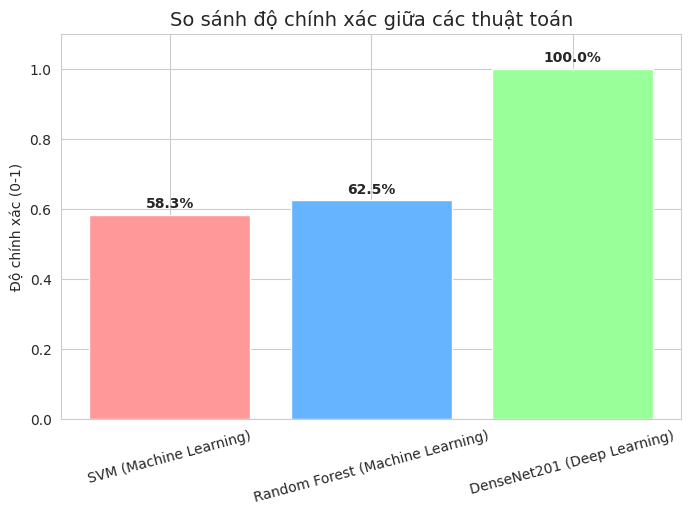

In [ ]:
import pandas as pd

# Tạo bảng so sánh
results = {
    'Mô hình': ['SVM (Machine Learning)', 'Random Forest (Machine Learning)', 'DenseNet201 (Deep Learning)'],
    'Độ chính xác (Accuracy)': [acc_svm, acc_rf, acc_dl],
    'Đánh giá': []
}

# Tự động đánh giá
for acc in results['Độ chính xác (Accuracy)']:
    if acc > 0.9: results['Đánh giá'].append('Xuất sắc ')
    elif acc > 0.8: results['Đánh giá'].append('Tốt ')
    elif acc > 0.7: results['Đánh giá'].append('Khá ')
    else: results['Đánh giá'].append('Cần cải thiện ')

df_results = pd.DataFrame(results)
df_results['Độ chính xác (Accuracy)'] = df_results['Độ chính xác (Accuracy)'].apply(lambda x: f"{x:.2%}")

# Hiển thị bảng
print("📊 BẢNG TỔNG HỢP SO SÁNH HIỆU QUẢ:")
display(df_results)

# Vẽ biểu đồ cột so sánh
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Mô hình'], [acc_svm, acc_rf, acc_dl], color=['#ff9999','#66b3ff','#99ff99'])
plt.title('So sánh độ chính xác giữa các thuật toán', fontsize=14)
plt.ylabel('Độ chính xác (0-1)')
plt.ylim(0, 1.1)

# Hiện số trên cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.1%}", ha='center', fontweight='bold')

plt.xticks(rotation=15)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Hàm in báo cáo đẹp bằng Pandas DataFrame
def print_report(y_true, y_pred, model_name):
    print(f"\n{'='*20} BÁO CÁO CHI TIẾT: {model_name} {'='*20}")
    # Trả về dict để chuyển thành DataFrame
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()

    # Làm tròn số cho đẹp
    display(df_report.style.background_gradient(cmap='Greens', subset=['f1-score', 'recall', 'precision']).format("{:.2%}"))

# 1. Báo cáo SVM
print_report(y_test, y_pred_svm, "SVM (Machine Learning)")

# 2. Báo cáo Random Forest
print_report(y_test, y_pred_rf, "Random Forest (Machine Learning)")

# 3. Báo cáo DenseNet201 (Deep Learning)
print_report(y_test, y_pred_dl, "DenseNet201 (Deep Learning)")


==================== BÁO CÁO CHI TIẾT: SVM (Machine Learning) ====================


,precision,recall,f1-score,support
Bacterial leaf blight,20.00%,75.00%,31.58%,400.00%
Brown spot,66.67%,28.57%,40.00%,700.00%
Leaf smut,83.33%,38.46%,52.63%,1300.00%
accuracy,41.67%,41.67%,41.67%,41.67%
macro avg,56.67%,47.34%,41.40%,2400.00%
weighted avg,67.92%,41.67%,45.44%,2400.00%



==================== BÁO CÁO CHI TIẾT: Random Forest (Machine Learning) ====================


,precision,recall,f1-score,support
Bacterial leaf blight,23.08%,75.00%,35.29%,400.00%
Brown spot,60.00%,42.86%,50.00%,700.00%
Leaf smut,83.33%,38.46%,52.63%,1300.00%
accuracy,45.83%,45.83%,45.83%,45.83%
macro avg,55.47%,52.11%,45.98%,2400.00%
weighted avg,66.49%,45.83%,48.97%,2400.00%



==================== BÁO CÁO CHI TIẾT: DenseNet201 (Deep Learning) ====================


,precision,recall,f1-score,support
Bacterial leaf blight,100.00%,100.00%,100.00%,400.00%
Brown spot,100.00%,100.00%,100.00%,700.00%
Leaf smut,100.00%,100.00%,100.00%,1300.00%
accuracy,100.00%,100.00%,100.00%,100.00%
macro avg,100.00%,100.00%,100.00%,2400.00%
weighted avg,100.00%,100.00%,100.00%,2400.00%


In [ ]:
import gradio as gr
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm

# --- CẤU HÌNH ---
vn_labels = {
    'Bacterial leaf blight': 'Bệnh Bạc Lá (Do vi khuẩn)',
    'Brown spot': 'Bệnh Đốm Nâu',
    'Leaf smut': 'Bệnh Than Đen'
}

# Đảm bảo bạn đã có biến 'dl_model' từ bước train
# Nếu biến tên là 'model_dense', hãy đổi dòng dưới thành: final_model = model_dense
try:
    final_model = dl_model
except NameError:
    print("❌ LỖI: Bạn chưa chạy bước huấn luyện mô hình! Hãy chạy lại các cell bên trên trước.")
    final_model = None

# --- HÀM GRAD-CAM THỦ CÔNG (TRÁNH LỖI OP:PACK) ---
def make_gradcam_heatmap_manual(img_array, model, last_conv_layer_name="conv5_block32_concat"):
    # 1. Tách model thành Base (DenseNet) và Classifier
    base_model = model.layers[0]
    classifier_layers = model.layers[1:] # Các lớp sau DenseNet

    # 2. Tạo model trích xuất đặc trưng từ Base
    try:
        last_conv_layer = base_model.get_layer(last_conv_layer_name)
    except ValueError:
        # Fallback nếu không tìm thấy layer
        last_conv_layer = base_model.layers[-1]

    conv_model = tf.keras.Model(base_model.input, last_conv_layer.output)

    # 3. Tính toán Gradient
    with tf.GradientTape() as tape:
        # A. Chạy qua phần Base
        conv_output = conv_model(img_array)
        tape.watch(conv_output)

        # B. Chạy thủ công qua phần Classifier
        x = conv_output
        for layer in classifier_layers:
            x = layer(x)

        preds = x
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    # 4. Tính đạo hàm & Heatmap
    grads = tape.gradient(top_class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# --- HÀM DỰ ĐOÁN & VẼ KHUNG ---
def predict_and_visualize(image):
    if image is None: return None, None

    try:
        # 1. Tiền xử lý
        original_img = cv2.resize(image, (224, 224))
        img_array = original_img / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        # 2. Dự đoán
        predictions = final_model.predict(img_batch).flatten()
        pred_index = np.argmax(predictions)
        top_label = class_names[pred_index]
        vn_name = vn_labels.get(top_label, top_label)

        confidences = {vn_labels.get(k, k): float(v) for k, v in zip(class_names, predictions)}

        # 3. Tạo Heatmap
        heatmap = make_gradcam_heatmap_manual(img_batch, final_model, "conv5_block32_concat")

        # 4. Xử lý ảnh hiển thị
        heatmap_uint8 = np.uint8(255 * heatmap)
        jet = cm.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap_uint8]
        jet_heatmap = cv2.resize((jet_heatmap * 255).astype('uint8'), (224, 224))

        # Chồng ảnh (Overlay)
        final_img = cv2.addWeighted(original_img, 0.7, jet_heatmap, 0.3, 0)

        # 5. KHOANH VÙNG (Bounding Box)
        # Tạo mask nhị phân từ heatmap
        _, thresh = cv2.threshold(heatmap_uint8, 100, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        found = False
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            # Chỉ vẽ nếu vùng đủ lớn (lớn hơn 50 pixel)
            if w * h > 50:
                # Vẽ khung chữ nhật Xanh Lá
                cv2.rectangle(final_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
                # Viết tên bệnh
                cv2.putText(final_img, vn_name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                found = True

        if not found and predictions[pred_index] > 0.5:
            cv2.rectangle(final_img, (0, 0), (224, 224), (0, 0, 255), 2)
            cv2.putText(final_img, f"Phat hien: {vn_name}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        return final_img, confidences

    except Exception as e:
        print(f"Lỗi: {e}")
        return image, {"Lỗi": str(e)}

# --- KHỞI CHẠY GRADIO ---
try:
    demo.close()
except:
    pass

with gr.Blocks(title="Chẩn Đoán Bệnh Lúa AI") as demo:
    gr.Markdown("# 🌾 Hệ Thống Chẩn Đoán & Khoanh Vùng Bệnh Lúa")
    gr.Markdown("Hệ thống sử dụng DenseNet201 + Grad-CAM để phát hiện và định vị vùng bệnh.")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(label="Tải ảnh gốc")
            btn_predict = gr.Button("🔍 Phân tích", variant="primary")

        with gr.Column():
            output_image = gr.Image(label="Kết quả khoanh vùng")
            output_label = gr.Label(num_top_classes=3, label="Tỉ lệ dự đoán")

    btn_predict.click(
        fn=predict_and_visualize,
        inputs=input_image,
        outputs=[output_image, output_label]
    )

if __name__ == "__main__":
    demo.launch(share=True, debug=True)

Closing server running on port: 7860
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e2d5534ab4ce4aaaa6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
